In [1]:
import h5py
import numpy as np
import tensorflow as tf                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
import matplotlib.pyplot as plt

var_sampling_mask (1, 1, 320, 1) float32 <class 'numpy.ndarray'>
Sampling: 0.234375
Number of 1s: 75 (23.43750000%)
Number of 0s: 245 (76.56250000%)
Min 0.0
Max 1.0
data range 1.0
var_sampling_mask (1, 1, 320, 1) float32 <class 'numpy.ndarray'>
var_sampling_mask[0] (1, 320, 1) float32 <class 'numpy.ndarray'>


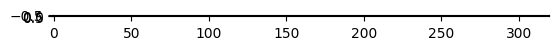

In [2]:
#hybrid_cascade/fastmri/Data/mask_4x_320_random.npy
var_sampling_mask=np.load(r"C:\Users\DU\aman_fastmri\Data\mask_4x_320_random.npy")
print("var_sampling_mask",var_sampling_mask.shape,var_sampling_mask.dtype,type(var_sampling_mask))


print("Sampling:", 1.0*var_sampling_mask.sum()/var_sampling_mask.size)
num_zeros = np.sum(var_sampling_mask[0] == 0)
num_ones = np.sum(var_sampling_mask[0] == 1)
# Print results
total_pixels = var_sampling_mask[0].size

# Calculate percentages
ones_percentage = (num_ones / total_pixels) * 100
zeros_percentage = (num_zeros / total_pixels) * 100

print(f"Number of 1s: {num_ones} ({ones_percentage:.8f}%)")
print(f"Number of 0s: {num_zeros} ({zeros_percentage:.8f}%)")
print("Min",var_sampling_mask[0].min())
print("Max",var_sampling_mask[0].max())
print("data range",var_sampling_mask[0].max()-var_sampling_mask[0].min())
print("var_sampling_mask",var_sampling_mask.shape,var_sampling_mask.dtype,type(var_sampling_mask))
print("var_sampling_mask[0]",var_sampling_mask[0].shape,var_sampling_mask[0].dtype,type(var_sampling_mask[0]))
plt.imshow(var_sampling_mask[0],cmap='gray')

In [3]:
import h5py
import numpy as np
import tensorflow as tf

class MRISliceGenerator(tf.keras.utils.Sequence):

    def __init__(self, file_list, mask, batch_size=4, shuffle=True):
        self.file_list = file_list
        self.batch_size = batch_size
        self.shuffle = shuffle

        # mask must be (1,1,W,1)
        self.mask = mask

        self.slice_index_map = []
        self._build_index()

    def _build_index(self):
        for file_idx, file_path in enumerate(self.file_list):
            with h5py.File(file_path, 'r') as f:
                num_slices = f['kspace_under'].shape[0]
                for slice_idx in range(num_slices):
                    self.slice_index_map.append((file_idx, slice_idx))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.slice_index_map) / self.batch_size))

    def __getitem__(self, index):

        batch_map = self.slice_index_map[
            index * self.batch_size:(index + 1) * self.batch_size
        ]

        kspace_batch = []
        target_img_batch = []

        for file_idx, slice_idx in batch_map:
            with h5py.File(self.file_list[file_idx], 'r') as f:

                kspace_under = f['kspace_under'][slice_idx]   # (H,W,2)
                target_img  = f['image_full'][slice_idx]     # (H,W,2)

                kspace_batch.append(kspace_under)
                target_img_batch.append(target_img)

        x_kspace = np.stack(kspace_batch, axis=0)
        y_batch  = np.stack(target_img_batch, axis=0)

        # expand mask to batch
        batch_size_actual = x_kspace.shape[0]
        mask_batch = np.tile(self.mask, (batch_size_actual, 1, 1, 1))

        return [x_kspace, mask_batch], y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.slice_index_map)

In [4]:
train_folder = r"E:\fastmri_singlecoil\train_norm"
val_folder = r"E:\fastmri_singlecoil\val_norm"

In [5]:
import h5py
import numpy as np
import glob
import os
#kspace_files_list_train = sorted(glob.glob(os.path.join(train_folder, "*.h5")))
kspace_files_list_val = sorted(glob.glob(os.path.join(val_folder, "*.h5")))

# half_train = 20
# half_val = 10
#half_train = len(kspace_files_list_train) 
half_val = len(kspace_files_list_val) 
# print("half_train",half_train)
# print("half_val",half_val)
#kspace_files_list_train = kspace_files_list_train[:half_train]
kspace_files_list_val = kspace_files_list_val[:half_val]

# Create generators
#train_gen = MRISliceGenerator(kspace_files_list_train,batch_size=4, shuffle=True,mask=var_sampling_mask)
val_gen = MRISliceGenerator(kspace_files_list_val, batch_size=4, shuffle=False,mask=var_sampling_mask)
# train_gen = MRISliceGenerator(kspace_files_list_train,batch_size=16, shuffle=True)
# val_gen = MRISliceGenerator(kspace_files_list_val, batch_size=4, shuffle=False)

#print(len(train_gen))  
print(len(val_gen))  


1784


In [6]:
import tensorflow as tf
from tensorflow.keras.losses import Loss

class PerpLoss(tf.keras.losses.Loss):
    def call(self, y_true, y_pred):
        # Split into real and imaginary components
        y_true_real, y_true_imag = y_true[..., 0], y_true[..., 1]
        y_pred_real, y_pred_imag = y_pred[..., 0], y_pred[..., 1]

        # Reconstruct complex tensors
        y_true_complex = tf.complex(y_true_real, y_true_imag)
        y_pred_complex = tf.complex(y_pred_real, y_pred_imag)

        # Magnitudes
        mag_pred = tf.abs(y_pred_complex)
        mag_target = tf.abs(y_true_complex)

        # Cross product magnitude
        cross = tf.abs(y_true_real * y_pred_imag - y_true_imag * y_pred_real)

        # Angle difference
        angle_true = tf.math.atan2(y_true_imag, y_true_real)
        angle_pred = tf.math.atan2(y_pred_imag, y_pred_real)
        angle_diff = angle_true - angle_pred

        # perp loss part
        ploss = cross / (mag_pred + 1e-8)
        phase = tf.math.cos(angle_diff)
        aligned_mask = tf.math.less(phase, 0.0)

        final_term = tf.where(aligned_mask,
                              mag_target + (mag_target - ploss),
                              ploss)

        # Combine with magnitude MSE
        mse_mag = tf.reduce_mean(tf.square(mag_pred - mag_target))
        total_loss = tf.reduce_mean(final_term + mse_mag)
        return total_loss




In [11]:
%run model.ipynb
#%run model_2_SA-Copy1.ipynb

In [12]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# --- Directory Setup ---
save_dir = "./SavedModels"
os.makedirs(save_dir, exist_ok=True)

# --- Configuration ---
H, W        = 320, 320

LEARNING_RATE = 1e-4

# define checkpoint & final weight filepaths (use .h5 for weights-only)
MODEL_NAME   = os.path.join(save_dir, "model_final.h5")
WEIGHTS_FINAL = os.path.join(save_dir, "model_final.h5")


print("=" * 60)
print("🔧 TRAINING CONFIGURATION")
print("=" * 60)
print(f" Save Directory:       {save_dir}")
print(f" Model Dimensions:     {H}x{W}")
print(f" Epochs:               {EPOCHS}")
print(f" Learning Rate:        {LEARNING_RATE}")
print(f" Checkpoint Weights:   {MODEL_NAME}")
print(f" Final Weights Path:   {WEIGHTS_FINAL}")
print("=" * 60)

# --- Model Setup ---
model = deep_cascade_with_intermediate_outputs(depth_str='ikikii',
        H=320,
        W=320,
        depth=5,
        kshape=(3,3),
        nf=48,
        channels=2
        )
# --- Optimizer & Compile ---
optimizer = Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss=PerpLoss())


🔧 TRAINING CONFIGURATION
 Save Directory:       ./SavedModels_model_2_SA_eachcnn
 Model Dimensions:     320x320
 Epochs:               31
 Learning Rate:        0.0001
 Checkpoint Weights:   ./SavedModels_model_2_SA_eachcnn\model_final.h5
 Final Weights Path:   ./SavedModels_model_2_SA_eachcnn\model_final.h5


In [13]:
# # --- Optimizer & Compile ---
# optimizer = Adam(learning_rate=LEARNING_RATE)
# model.compile(optimizer=optimizer, loss=PerpLoss())

# --- Load Existing Best Weights ---
if os.path.isfile(MODEL_NAME):
    try:
        model.load_weights(MODEL_NAME)
        print(f"Loaded checkpoint weights from {MODEL_NAME}")
    except Exception as e:
        print(f" Could not load checkpoint: {e}\n   Starting from scratch.")
else:
    print("No existing checkpoint found. Starting from scratch.")

Loaded checkpoint weights from ./SavedModels_model_2_SA_eachcnn\model_final.h5


In [ ]:
import os
import numpy as np
import h5py
import glob
from tqdm import tqdm
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# Path to validation folder
# val_folder = "F:/denoised_preprocessed_h5_val"

# val_folder = r"E:\fastmri\val_norm"
# val_folder = r"D:\val_norm"

# val_folder = r"G:\val_norm\val_norm"
# files = sorted([os.path.join(val_folder, f) for f in os.listdir(val_folder) if f.endswith(".h5")])
kspace_files_list_val = sorted(glob.glob(os.path.join(val_folder, "*.h5")))
file_paths = kspace_files_list_val


# ----------------------
# HELPERS
# ----------------------
def to_complex(x):
    return x[..., 0] + 1j * x[..., 1]

def nmse(gt, pred):
    return np.linalg.norm(gt - pred) ** 2 / (np.linalg.norm(gt) ** 2 + 1e-10)

def compute_ssim(gt, pred, max_val):
    return structural_similarity(
        gt, pred,
        data_range=max_val,
        win_size=7,
        gaussian_weights=False,
        use_sample_covariance=False,
        K1=0.01,
        K2=0.03
    )

# ----------------------
# STORAGE
# ----------------------
ssim_list = []
psnr_list = []
nmse_list = []

# ----------------------
# PROCESSING
# ----------------------
for file in tqdm(file_paths, desc="Processing volumes"):
    with h5py.File(file, 'r') as f:
        image_full = f["image_full"][:]       # (slices, H, W, 2)
        image_under = f["image_under"][:]     # (slices, H, W, 2)
        max_val = float(f["max_val_full_image"][0])
        #image_under = f["image_under"][:]

    #mask_batch = np.tile(var_sampling_mask, (image_under.shape[0], 1, 1, 1)) 
    # Get model prediction (still in normalized form)
    #pred = model.predict([image_under,mask_batch], verbose=0)  # shape (slices, H, W, 2)
    #pred = model.predict(image_under, verbose=0)  # shape (slices, H, W, 2)
    
    image_full *= max_val
    
    image_under *= max_val  # Scale predicted output to original intensity range

    # Convert to complex and get magnitude
    gt_mag = np.abs(to_complex(image_full))
    pred_mag = np.abs(to_complex(image_under))

    # Volume-wise PSNR and NMSE
    psnr_val = peak_signal_noise_ratio(gt_mag, pred_mag, data_range=max_val)
    nmse_val = nmse(gt_mag.flatten(), pred_mag.flatten())

    psnr_list.append(psnr_val)
    nmse_list.append(nmse_val)

    # Slice-wise SSIM
    for i in range(gt_mag.shape[0]):
        ssim_val = compute_ssim(gt_mag[i], pred_mag[i], max_val)
        ssim_list.append(ssim_val)

# ----------------------
# REPORT
# ----------------------

print("\n" + "=" * 40)
print(f"PSNR (Mag, volume): {np.mean(psnr_list):.2f} ± {np.std(psnr_list):.2f} dB")
print(f"NMSE (Mag, volume): {np.mean(nmse_list):.6f} ± {np.std(nmse_list):.6f}")
print(f"SSIM (Mag, slice):  {np.mean(ssim_list):.4f} ± {np.std(ssim_list):.4f}")

print("=" * 40)


In [14]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import h5py

# ============================================================
# SETTINGS
# ============================================================

#val_folder = "PATH_TO_YOUR_VAL_FOLDER"   # 🔥 change this
output_dir = "attention_maps_eachcnn_revised"

os.makedirs(output_dir, exist_ok=True)

# ============================================================
# DATA
# ============================================================

kspace_files_list_val = sorted(glob.glob(os.path.join(val_folder, "*.h5")))
file_paths = kspace_files_list_val

selected_files = file_paths[:5]
slice_indices = [30, 20, 16, 7, 32]

num_cascades = 6  # since 'ikikii'

# ============================================================
# MAIN LOOP
# ============================================================

for row, (file, slice_idx) in enumerate(zip(selected_files, slice_indices)):

    print(f"Processing Row {row+1} | File: {os.path.basename(file)} | Slice: {slice_idx}")

    with h5py.File(file, 'r') as f:
        kspace_under = f["kspace_under"][:]

    # Slice selection
    k_under_slice = kspace_under[slice_idx:slice_idx+1]

    # Mask batch
    mask_batch = np.tile(var_sampling_mask, (1, 1, 1, 1))

    # ========================================================
    # MODEL PREDICTION
    # ========================================================

    outputs = model.predict([k_under_slice, mask_batch], verbose=0)

    # Skip cascades + final output → get attention maps
    attention_outputs = outputs[num_cascades + 1:]

    # ========================================================
    # SAVE EACH ATTENTION MAP
    # ========================================================

    for col in range(num_cascades):

        att = attention_outputs[col]

        # -----------------------------------
        # Convert frequency blocks
        # -----------------------------------
        if col in [1, 3]:  # frequency blocks

            real = att[..., 0]
            imag = tf.zeros_like(real)

            att_complex = tf.stack([real, imag], axis=-1)

            # IFFT → image domain
            att_ifft = ifft2c_tf(att_complex).numpy()

            att_map = np.abs(
                att_ifft[0, ..., 0] + 1j * att_ifft[0, ..., 1]
            )

        else:
            att_map = att[0, ..., 0]

        # -----------------------------------
        # Normalize
        # -----------------------------------
        att_map = (att_map - att_map.min()) / (att_map.max() + 1e-8)

        # -----------------------------------
        # Plot + Save
        # -----------------------------------
        plt.figure(figsize=(3, 3))
        plt.imshow(att_map, cmap='viridis')
        plt.axis('off')

        save_path = os.path.join(
            output_dir,
            f"row{row+1}_col{col+1}.png"
        )

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches='tight',
            pad_inches=0
        )

        plt.close()  # 🔥 prevents memory leak

# ============================================================
# DONE
# ============================================================

print("\n✅ All attention maps saved successfully!")

Processing Row 1 | File: volume_000.h5 | Slice: 30
Processing Row 2 | File: volume_001.h5 | Slice: 20
Processing Row 3 | File: volume_002.h5 | Slice: 16
Processing Row 4 | File: volume_003.h5 | Slice: 7
Processing Row 5 | File: volume_004.h5 | Slice: 32

✅ All attention maps saved successfully!
